# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Elegir medios y artículos adecuados | Sugerencias sobre posibles corpus | Recomendó 5 artículos por medio | El criterio de selección (temática consistente, acceso libre, dos grupos diferenciados) | Artículos sugeridos demasiado cortos o con dificultad para scrappear |
| Procesamiento con spaCy | Entender qué hacen las funciones de lematización y filtrado | ¿Qué diferencia hay entre texto_lemas y texto_contenido? | Explicó que texto_lemas conserva todo lematizado y texto_contenido filtra stopwords; útil para entender qué se vectoriza | La distinción conceptual para justificar el uso de texto_contenido en BoW y TF-IDF | La sugerencia de modificar el pipeline de spaCy: el código dado en la notebook era suficiente |
| Representaciones sparse | Comprender la diferencia entre BoW y TF-IDF | ¿Por qué TF-IDF puede mostrar términos distintos a los más frecuentes? | Explicó que TF-IDF penaliza términos compartidos: un término específico de un grupo tendrá peso alto aunque no sea el más frecuente | La intuición central para la interpretación comparada en la sección 10 | La sugerencia de usar min_df=2, demasiado restrictivo con solo 5 documentos por grupo |
| Visualización | Interpretar el mapa de calor de TF-IDF | ¿Qué debo mirar primero en el heatmap? | Indicó que hay que observar las celdas más oscuras por columna e identificar términos con peso alto en solo uno de los grupos | El criterio para distinguir términos distintivos de compartidos | La recomendación de cambiar paleta de color: "mako" era suficientemente legible |
| Gráfico de bigramas | Visualizar los bigramas como gráfico comparativo, no solo como tabla | ¿Se puede agregar un gráfico de bigramas por grupo? | Generó código con dos paneles de barras horizontales | El gráfico completo: muestra bigramas como "hombre desconfiar", "mil millón" y "modelo lenguaje" que la tabla sola no comunicaba visualmente | Descarte los colores y adapte a la paleta de la Notebook |
| Vocabulario exclusivo vs. compartido | Cuantificar la separación léxica entre grupos antes de BoW/TF-IDF | ¿Se puede agregar una tabla y gráfico que muestre cuánto vocabulario comparten los grupos? | Generó código que calcula vocabulario exclusivo de cada grupo y compartido, con tabla de conteos/porcentajes + gráfico de torta | Ambas visualizaciones: la tabla da los números, el gráfico de torta hace visible la proporción y anticipa por qué BoW y TF-IDF convergen en este corpus | La sugerencia de incluir también bigramas exclusivos, porque hubiera complejizado la cosa |
| Interpretación final | Revisar solidez de las conclusiones a la luz de los fragmentos reales | "Estas conclusiones son sostenibles con lo que mostraron los fragmentos? | Señaló que los fragmentos confirmaban el contraste pero matizaban dos términos: `equipo` es artefacto temático y `ai` es artefacto del scraping; `definición` sí es marca enunciativa real | La actualización de la sección 10 incorporando los hallazgos de lectura cercana como corrección y no solo como confirmación | La sugerencia de agregar análisis de sentimiento, por que me supera |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [2]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_md"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [3]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 10
Grupos detectados: ['Anfibia', 'Cenital']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,c01,2025-10-16,Cenital,Cenital,La burbuja de la inteligencia artificial,Cenital,1598
1,c02,2026-04-23,Cenital,Cenital,"La inteligencia artificial no muestra el pasado, lo reescribe",Cenital,1443
2,c03,2025-05-13,Cenital,Cenital,"Espectros, vampiros y fantasmas: ¿para esto usamos la inteligencia artificial?",Cenital,2307
3,c04,2025-05-13,Cenital,Cenital,Una nueva vida no biológica: ¿qué tan gobernados estamos por la inteligencia artificial?,Cenital,2084
4,c05,2024-12-13,Cenital,Cenital,La inteligencia artificial no previene la estupidez natural,Cenital,2976
5,a01,2024-09-16,Anfibia,Anfibia,Es lo que AI,Anfibia,1912
6,a02,2023-09-22,Anfibia,Sofía Trejo,"Inteligencia artificial, pero a qué costo",Anfibia,2994
7,a03,2023-04-13,Anfibia,Anfibia,Inteligencia Artificial (dossier),Anfibia,4141
8,a04,2023-04-25,Anfibia,Anfibia,¿Hacia dónde nos lleva la inteligencia artificial?,Anfibia,1161
9,a05,2025-08-27,Anfibia,Anfibia,Una IA latinoamericana es posible,Anfibia,3869


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


### Justificación del recorte

**¿Qué comparamos exactamente?**

Comparamos la cobertura periodística y ensayística de la inteligencia artificial (IA) en dos medios digitales argentinos: *Cenital* y *Revista Anfibia*. El corpus está compuesto por cinco artículos de cada medio, publicados entre 2023 y 2026, todos centrados en la IA como tema principal.

**¿Por qué este corpus y no otro?**

Porque representan dos tradiciones discursivas claramente diferenciadas dentro del periodismo digital. *Cenital* se define como un medio de periodismo informativo y de análisis, con una escritura más directa, orientada a explicar fenómenos de actualidad. *Anfibia*, vinculada a la UNSAM, tiene una impronta más ensayística y académico-popular, con mayor presencia de voces críticas y marcos teóricos explícitos. Ambos medios son de acceso libre, lo que facilita la reproducibilidad del corpus, y tienen producción sostenida sobre tecnología e IA.

**¿Qué vuelve comparables a los dos grupos?**

Los dos grupos son comparables porque:
- Comparten la temática (inteligencia artificial) de forma consistente en todos los textos.
- Son medios de alcance nacional, en español rioplatense.
- Los textos tienen extensiones similares (artículos de entre 1000 y 2500 palabras aproximadamente).
- Fueron publicados en un período temporal solapado (2023–2026), lo que evita distorsiones por contexto histórico muy dispar.

**¿Qué límites iniciales ya vemos en el recorte?**

- Corpus pequeño (10 textos en total): los resultados son indicativos, no generalizables a toda la producción de cada medio.
- *Cenital* tiene muchos columnistas y estilos; los cinco artículos seleccionados pueden no capturar toda su variación.
- *Anfibia* incluye algunas voces de autoras externas (como Sofía Trejo), lo que introduce heterogeneidad dentro del grupo.
- El scraping con trafilatura puede haber incorporado elementos de navegación o paratexto que no forman parte del cuerpo del artículo.


## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [4]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,10
1,palabras aproximadas,24485
2,promedio por texto,2448.5
3,grupo 1,Anfibia
4,grupo 2,Cenital


In [5]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,Anfibia,5,14077,2815.4
1,Cenital,5,10408,2081.6


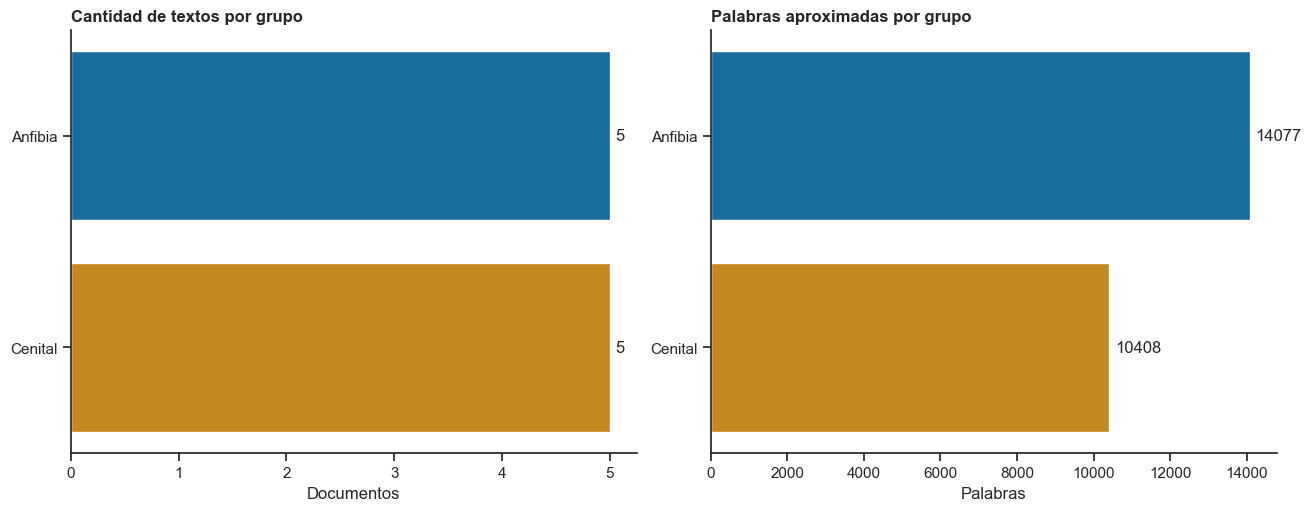

In [6]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


* Ambos grupos tienen la misma cantidad de documentos, 5 y 5.
* Anfibia tiene aprox.un 35% más de palabras que Cenital (14077 vs 10408).  
Ese desbalance en la longitud hay que tenerlo en cuenta. Un término más frecuente en Anfibia podría deberse al mayor volúmen de texto y no necesariamente porque use ese vocabulario. Por eso la comparación via TF-IDF va a ser mas confiable que BoW.

## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [7]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_md


In [8]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,La burbuja de la inteligencia artificial,Cenital,proyectar empresa tecnología estadounidense gastar año mil millón dólares inteligencia artificial cifra guardar demasiado relación ganan...
1,"La inteligencia artificial no muestra el pasado, lo reescribe",Cenital,febrero openai presentar sociedad sora generador video buscar deslumbrar ejemplo producido texto imagen histórico california fiebre oro ...
2,"Espectros, vampiros y fantasmas: ¿para esto usamos la inteligencia artificial?",Cenital,película recordar producir sensación inquietante sexto sentido night shyamalan protagonizado bruce willis jovencísimo haley joel osment ...
3,Una nueva vida no biológica: ¿qué tan gobernados estamos por la inteligencia artificial?,Cenital,desarrollar inteligencia superar decantar forma vida biológico justo hacer momento noticia llamar atención minuto comienzo inteligencia ...
4,La inteligencia artificial no previene la estupidez natural,Cenital,holis andás acá contemplar hoja excel llamado proyectos compruebo satisfacción cumplí tiempo forma cosa resultar sumamente desafiant cre...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [9]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,Anfibia,ia,99
1,Anfibia,sistema,70
2,Anfibia,él,59
3,Anfibia,dato,51
4,Anfibia,modelo,42
5,Anfibia,tarea,40
6,Anfibia,artificial,38
7,Anfibia,desarrollo,34
8,Anfibia,mundo,31
9,Anfibia,inteligencia,31


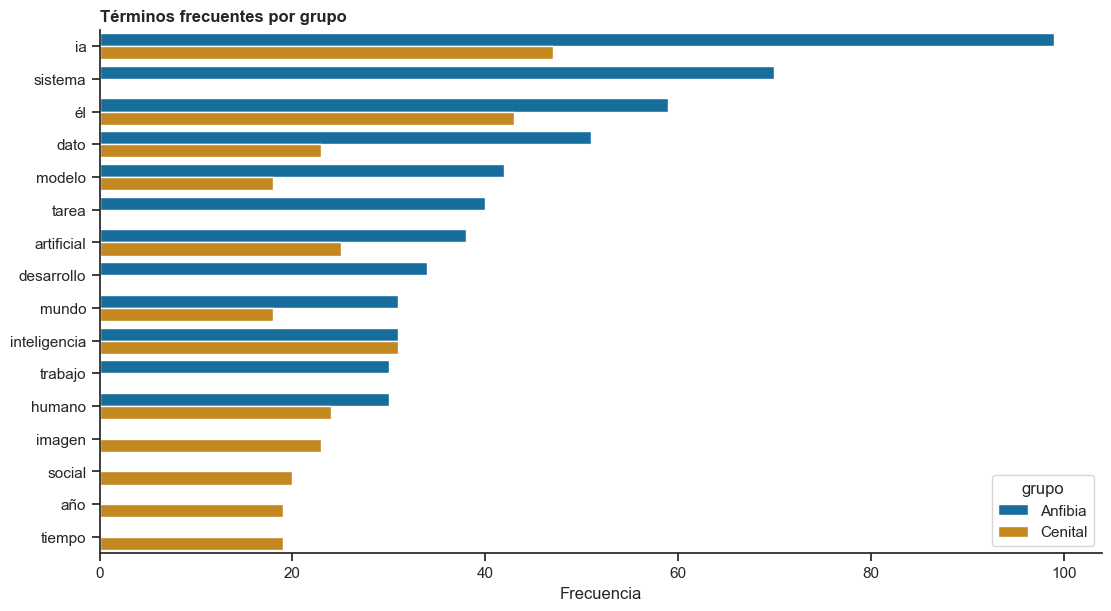

In [10]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [11]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
231,Anfibia,IA,MISC,25
232,Anfibia,IA,ORG,18
80,Anfibia,ChatGPT,MISC,14
293,Anfibia,LatamGPT,MISC,14
211,Anfibia,Google,ORG,13
198,Anfibia,GPT-4,MISC,9
378,Anfibia,OpenAI,ORG,8
74,Anfibia,Cenia,LOC,7
468,Anfibia,Slack,MISC,7
485,Anfibia,Sur,LOC,7


In [12]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,Anfibia,inteligencia artificial,26
1,Anfibia,sistema ia,20
2,Anfibia,of the,8
3,Anfibia,rapa nui,8
4,Anfibia,desarrollo ia,8
5,Anfibia,crear sistema,7
6,Anfibia,the acm,7
7,Anfibia,modelo lenguaje,7
8,Anfibia,hombre desconfiar,7
9,Anfibia,crear modelo,7


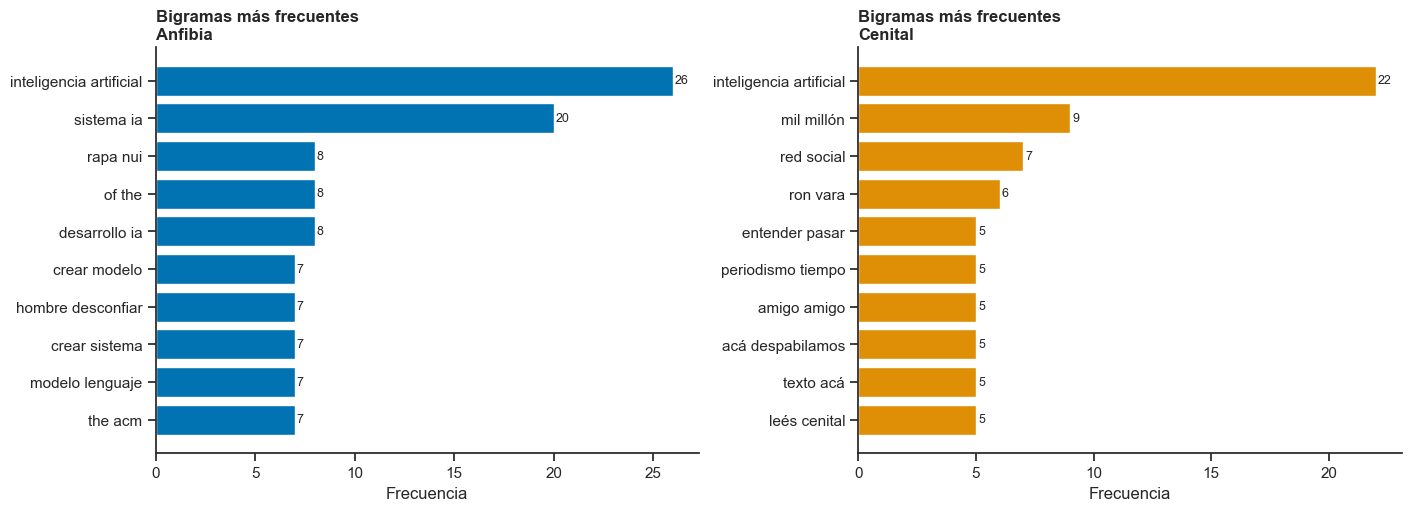

In [22]:
# Gráfico comparativo: top bigramas por grupo
# Tomamos los top-10 de cada grupo
top_bigramas_graf = (
    top_bigramas.groupby("grupo").head(10).copy()
)

grupos_unicos = sorted(top_bigramas_graf["grupo"].unique())
fig, axes = plt.subplots(
    1, len(grupos_unicos),
    figsize=(14, 5),
    constrained_layout=True,
    sharey=False,
)

for ax, grupo in zip(axes, grupos_unicos):
    datos = (
        top_bigramas_graf[top_bigramas_graf["grupo"] == grupo]
        .sort_values("frecuencia", ascending=True)
    )
    color = PALETA[0] if grupo == grupos_unicos[0] else PALETA[1]
    ax.barh(datos["bigrama"], datos["frecuencia"], color=color)
    ax.set_title(f"Bigramas más frecuentes\n{grupo}", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    for i, (val, lab) in enumerate(zip(datos["frecuencia"], datos["bigrama"])):
        ax.text(val + 0.1, i, str(val), va="center", fontsize=9)
    sns.despine(ax=ax)

plt.show()


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


#### Lo que necesita volver al texto:

* "hombre desconfiar" en Anfibia — la frecuencia 7 sugiere que es recurrente, pero hay que ver el contexto.
* "ron vara" en Cenital — es un autor o fuente citada repetidamente?. Si es así, está inflando bigramas sin un valor real.
* "rapa nui" en Anfibia — aparece 8 veces, mucho para un artículo sobre IA. Probable caso de estudio en uno de los artículos y está distorsionando los bigramas.

### Vocabulario exclusivo vs. compartido entre grupos

Antes de pasar a BoW y TF-IDF, conviene cuantificar cuánto vocabulario comparten realmente los dos grupos. Esta tabla hace explícito lo que el heatmap solo insinúa visualmente.

,categoría,cantidad de términos,% del vocabulario total,ejemplos representativos
0,Solo Anfibia,1593,41.9,"abandonir, abc, abecedario, abogada, abogar, abordar, abstracción, abundancia"
1,Compartido por ambos,931,24.5,"abierto, abrir, absolutamente, academia, académico, acceder, acción, aceptable"
2,Solo Cenital,1280,33.6,"abandonar, abrazar, abril, abrupto, absoluto, abundar, acercar, acero"


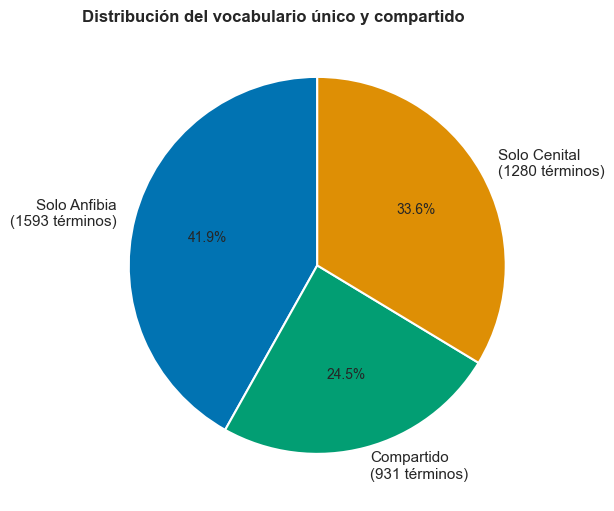

In [14]:
# Vocabulario exclusivo vs. compartido entre grupos
# Usamos el texto de contenido (sin stopwords) concatenado por grupo

vocab_por_grupo = {}
for grupo, subdf in df.groupby(COLUMNA_GRUPO):
    palabras = set(" ".join(subdf["texto_contenido"]).split())
    vocab_por_grupo[grupo] = palabras

grupos = list(vocab_por_grupo.keys())
vocab_a = vocab_por_grupo[grupos[0]]
vocab_b = vocab_por_grupo[grupos[1]]

solo_a = vocab_a - vocab_b
solo_b = vocab_b - vocab_a
compartido = vocab_a & vocab_b

# Tabla resumen de conteos
resumen_vocab = pd.DataFrame({
    "categoría": [
        f"Solo {grupos[0]}",
        "Compartido por ambos",
        f"Solo {grupos[1]}",
    ],
    "cantidad de términos": [len(solo_a), len(compartido), len(solo_b)],
    "% del vocabulario total": [
        round(len(solo_a) / (len(solo_a) + len(compartido) + len(solo_b)) * 100, 1),
        round(len(compartido) / (len(solo_a) + len(compartido) + len(solo_b)) * 100, 1),
        round(len(solo_b) / (len(solo_a) + len(compartido) + len(solo_b)) * 100, 1),
    ],
    "ejemplos representativos": [
        ", ".join(sorted(solo_a)[:8]),
        ", ".join(sorted(compartido)[:8]),
        ", ".join(sorted(solo_b)[:8]),
    ],
})

display(resumen_vocab)

# Gráfico de torta con los tres segmentos
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
sizes = [len(solo_a), len(compartido), len(solo_b)]
labels = [
    f"Solo {grupos[0]}\n({len(solo_a)} términos)",
    f"Compartido\n({len(compartido)} términos)",
    f"Solo {grupos[1]}\n({len(solo_b)} términos)",
]
colors = [PALETA[0], PALETA[2], PALETA[1]]
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Distribución del vocabulario único y compartido", fontweight="bold", loc="left")
plt.show()


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [15]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,Anfibia,abandonir esperanza dante divina comedia verano ver búsqueda empleo linkedin entrenar ia cambio escribir inglés prometer paraíso freelan...
1,Cenital,proyectar empresa tecnología estadounidense gastar año mil millón dólares inteligencia artificial cifra guardar demasiado relación ganan...


In [16]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,Anfibia,equipo,20.0
1,Anfibia,ai,18.0
2,Anfibia,latamgpt,16.0
3,Anfibia,of,16.0
4,Anfibia,exactitud,15.0
5,Anfibia,universidad,13.0
6,Anfibia,cenia,13.0
7,Anfibia,utilizado,12.0
8,Anfibia,métrica,11.0
9,Anfibia,and,10.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,Anfibia,equipo,0.2177
1,Anfibia,ai,0.1959
2,Anfibia,latamgpt,0.1742
3,Anfibia,of,0.1742
4,Anfibia,exactitud,0.1633
5,Anfibia,universidad,0.1415
6,Anfibia,cenia,0.1415
7,Anfibia,utilizado,0.1306
8,Anfibia,métrica,0.1197
9,Anfibia,and,0.1089


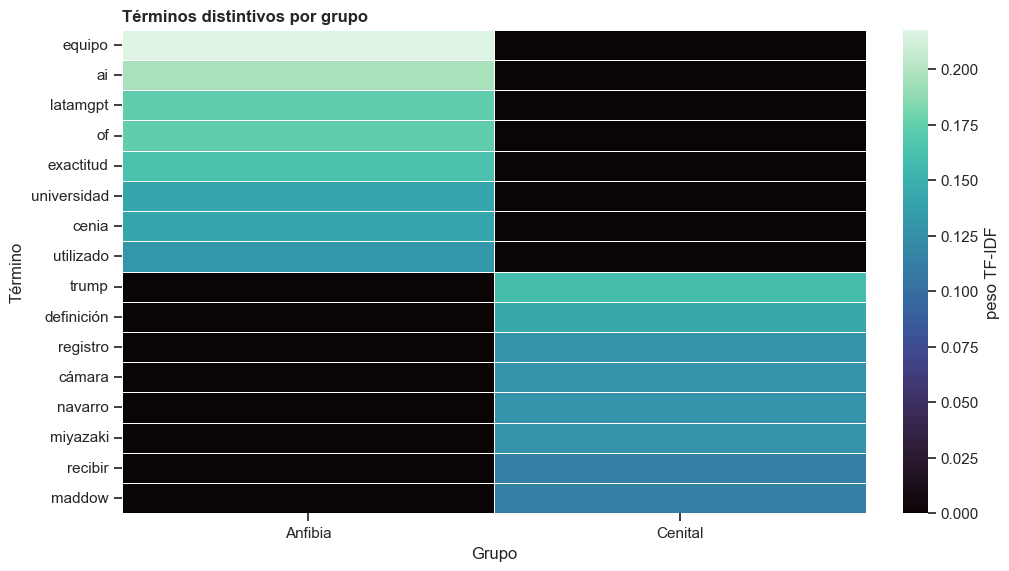

In [17]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


El heatmap muestra que los dos grupos tienen vocabularios que no se solapan prácticamente: los términos con peso alto en Anfibia tienen peso cero en Cenital y viceversa. 
* En Anfibia, los términos más distintivos (equipo, latamgpt, exactitud, universidad, cenia, métrica) provienen en su mayoría del artículo sobre LatamGPT, el proyecto de IA de la UNSAM.
* En Cenital, términos más distintivos (trump, miyazaki, maddow, navarro, cámara, registro, defición) revelan que varios artículos abordan la IA de forma indirecta: como herramienta de desinformación política, como problema de verificación periodística. La IA no es siempre el objeto central sino el instrumento analítico.
BoW y TF-IDF producen listas casi idénticas porque la separación léxica entre grupos es tan marcada que TF-IDF no tiene términos compartidos que penalizar.
* Volumen vs. especificidad:
En este caso, BoW y TF-IDF dan casi la misma lista porque los vocabularios son tan separados que TF-IDF no tiene mucho que penalizar: no hay términos que aparezcan en ambos grupos y que haya que "desinflar" (límite del corpus pequeño).

## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [18]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,Anfibia,equipo,0.2177
1,Anfibia,ai,0.1959
2,Cenital,trump,0.1596
3,Cenital,definición,0.1437


In [19]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,Anfibia,equipo,"Inteligencia artificial, pero a qué costo","...plicándose cada dos años [1]. Durante esta etapa, diversos grupos de investigación utilizaban el mismo tipo de software y de hardware..."
1,Anfibia,equipo,Una IA latinoamericana es posible,"...car lo que están haciendo en el Cenia, el Centro Nacional de Inteligencia Artificial de Chile, donde ella hace su postdoctorado y dir..."
2,Anfibia,ai,"Inteligencia artificial, pero a qué costo","...capacidad de crear estrategias conjuntas que nos permitan caminar hacia ellos.\n[1] Ahmed, N., & Wahed, M. (2020). The de-democratiza..."
3,Cenital,trump,"Espectros, vampiros y fantasmas: ¿para esto usamos la inteligencia artificial?","...realidad una IA”. Glup. Antes de que se develara que el supuesto hongkonés es un espectro, yo había leído alabanzas a su libro Hipnoc..."
4,Cenital,trump,Una nueva vida no biológica: ¿qué tan gobernados estamos por la inteligencia artificial?,...ra seguir.\nSumateStorm-2035\nLa influencia de la IA en las elecciones no es una amenaza potencial. En las últimas elecciones que gan...
5,Cenital,definición,La burbuja de la inteligencia artificial,"...nformación que leés en Cenital te ayuda a entender mejor lo que pasa, te pedimos que nos des una mano para seguir.\nSumateUna burbuja..."
6,Cenital,definición,La inteligencia artificial no previene la estupidez natural,...para saber dónde estamos paradas para hablar de inteligencia artificial (IA). Va un resumen.\n¿Qué es la inteligencia artificial?\n- ...


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


### Análisis interpretativo

---

#### 1. Recorte y comparación

Comparamos cinco artículos de *Cenital* y cinco de *Revista Anfibia* que abordan la inteligencia artificial como tema central, publicados entre 2023 y 2026. Lo que vuelve válido este contraste no es solo que ambos hablen de IA, sino que lo hacen desde posiciones enunciativas distintas: Cenital opera desde la lógica del periodismo explicativo-informativo, con una escritura más directa orientada a explicar fenómenos de actualidad. *Anfibia*, vinculada a la UNSAM, tiene una impronta más ensayística y académico-popular, con mayor presencia de voces críticas y marcos teóricos explícitos. Ambos comparten público letrado, registro en español rioplatense y acceso abierto, lo que permite aislar la variable discursiva del soporte institucional.

---

#### 2. Lectura distante

El análisis de frecuencias brutas (Bag of Words) mostró un vocabulario esperablemente compartido en la superficie temática, pero el heatmap de TF-IDF reveló que los dos grupos tienen vocabularios prácticamente no solapados: los términos con peso alto en Anfibia tienen peso cero en Cenital y viceversa.

En *Anfibia*, los términos más distintivos (`equipo`, `latamgpt`, `exactitud`, `universidad`, `cenia`, `métrica`) provienen mayormente del artículo sobre LatamGPT, el proyecto de IA de la UNSAM. El vocabulario apunta a un encuadre técnico-académico con orientación regional y crítica, reforzado por la presencia de entidades como *Sur*, *LatamGPT* y *ASI*.

En *Cenital*, los términos más distintivos (`trump`, `miyazaki`, `maddow`, `cámara`, `registro`,`definición`) revelan que varios artículos abordan la IA de forma indirecta: como herramienta de desinformación política, como problema de verificación periodística. La IA no es siempre el objeto central sino el instrumento analítico.

En este corpus, BoW y TF-IDF producen listas casi idénticas porque la separación léxica entre grupos es tan marcada que TF-IDF no tiene términos compartidos que penalizar. Esa coincidencia es en sí misma un dato: con más textos y mayor variedad interna, TF-IDF empezaría a separarse de BoW y revelaría contrastes más finos.

---

#### 3. Lectura cercana

La vuelta a los fragmentos confirmó algunas hipótesis y corrigió otras.

El término `equipo` en Anfibia no refleja una preferencia discursiva general del medio sino un artefacto temático: el artículo 'Una IA latinoamericana es posible' narra el proceso colaborativo de construcción de LatamGPT y necesariamente nombra a sus actores colectivos. Esto ilustra un límite real del corpus pequeño: un artículo con vocabulario muy específico puede dominar el perfil léxico del grupo entero.

El término `ai` en Anfibia proviene de referencias bibliográficas en inglés incorporadas al cuerpo del texto (por ejemplo, 'Ahmed, N., & Wahed, M. (2020). The de-democratiza...'). No es una elección discursiva sino un artefacto del scraping: trafilatura extrajo las citas junto al artículo. Esto limita la interpretación de términos en inglés como `ai`, `of` y `and` que aparecen en el top de Anfibia.

El término `definición` en Cenital fue el más revelador. En 'La inteligencia artificial no previene la estupidez natural', aparece en un segmento explícitamente didáctico donde el artículo detiene su argumento para preguntar '¿Qué es la inteligencia artificial?' y ofrecer una respuesta accesible. Este gesto —definir para el lector— es una marca enunciativa característica del periodismo explicativo: Cenital construye un pacto de lectura pedagógico donde la definición es parte del contrato con la audiencia, a diferencia de Anfibia, que asume mayor capital cultural y apela directamente a referencias académicas.

---

#### 4. Visualización y límites del método

El gráfico más útil para comprender el contraste fue el **mapa de calor de TF-IDF**: permitió ver de un vistazo qué términos eran privativos de cada grupo y confirmar visualmente la casi nula superposición léxica entre ambos. El gráfico de barras de frecuencias, en cambio, tendió a mostrar el vocabulario compartido y fue menos discriminante.

**Límites del enfoque:**

- Las representaciones sparse trabajan sobre lemas y frecuencias, pero no capturan la *sintaxis* ni la *modalidad enunciativa*: dos textos pueden usar el mismo término en contextos completamente opuestos.
- Con 10 documentos, los resultados son sensibles a la selección: un artículo con vocabulario muy específico (como el de LatamGPT en Anfibia) puede dominar el perfil léxico de todo el grupo.
- El scraping con trafilatura incorporó artefactos: referencias bibliográficas en inglés, llamados a suscripción y otros paratextos que distorsionan el vocabulario.
- No es posible afirmar con estas herramientas que *Cenital* siempre es más pedagógico o que *Anfibia* siempre es más crítica. Lo que sí podemos decir es que, **en estos diez textos sobre IA**, emergen patrones léxicos consistentes con esas hipótesis, que la vuelta a los fragmentos confirma.


In [20]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
